# 🧬 Stanford RNA 3D Folding 2: Expanded EDA & Visualization 📊

Welcome to this Exploratory Data Analysis (EDA) notebook! 🚀

In this notebook, we will:
1.  **Analyze Sequence Lengths**: Understand the distribution of RNA lengths. 📏
2.  **Check Character Composition**: See the balance of A, U, G, C bases. 🧬
3.  **Ligand Analysis**: See what molecules bind to our RNAs. 💊
4.  **Stoichiometry**: Analyze single vs. multi-chain complexes. 🧩
5.  **WordCloud**: Visualize common terms in RNA descriptions. ☁️
6.  **Visualize 3D Structures**: Plot the 3D coordinates. 🧊

Let's dive in! 🌊

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from collections import Counter
from wordcloud import WordCloud

# 🎨 Set plot style for better aesthetics
sns.set_theme(style="whitegrid")

# 📁 Define the base directory for Kaggle environment
BASE_DIR = '/kaggle/input/stanford-rna-3d-folding-2'

print("✅ Setup complete!")

✅ Setup complete!


## 1. Loading Data 📜
We load the `train_sequences.csv`.

In [2]:
print("⏳ Loading train_sequences.csv...")
df_seq = pd.read_csv(f'{BASE_DIR}/train_sequences.csv')

print(f"📌 Sequences shape: {df_seq.shape}")
df_seq.head()

⏳ Loading train_sequences.csv...
📌 Sequences shape: (5716, 8)


,target_id,sequence,temporal_cutoff,description,stoichiometry,all_sequences,ligand_ids,ligand_SMILES
0,4TNA,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1978-04-12,FURTHER REFINEMENT OF THE STRUCTURE OF YEAST T...,A:1,>4TNA_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG,[Mg+2]
1,6TNA,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1979-01-16,CRYSTAL STRUCTURE OF YEAST PHENYLALANINE T-RNA...,A:1,>6TNA_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG,[Mg+2]
2,1TRA,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1986-07-14,RESTRAINED REFINEMENT OF THE MONOCLINIC FORM O...,A:1,>1TRA_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG,[Mg+2]
3,1TN2,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1986-10-24,CRYSTALLOGRAPHIC AND BIOCHEMICAL INVESTIGATION...,A:1,>1TN2_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG;PB;SPM,[Mg+2];[Pb+2];C(CCNCCCN)CNCCCN
4,1TN1,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1987-01-15,CRYSTALLOGRAPHIC AND BIOCHEMICAL INVESTIGATION...,A:1,>1TN1_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG;PB;SPM,[Mg+2];[Pb+2];C(CCNCCCN)CNCCCN


## 2. Sequence Length Distribution 📏

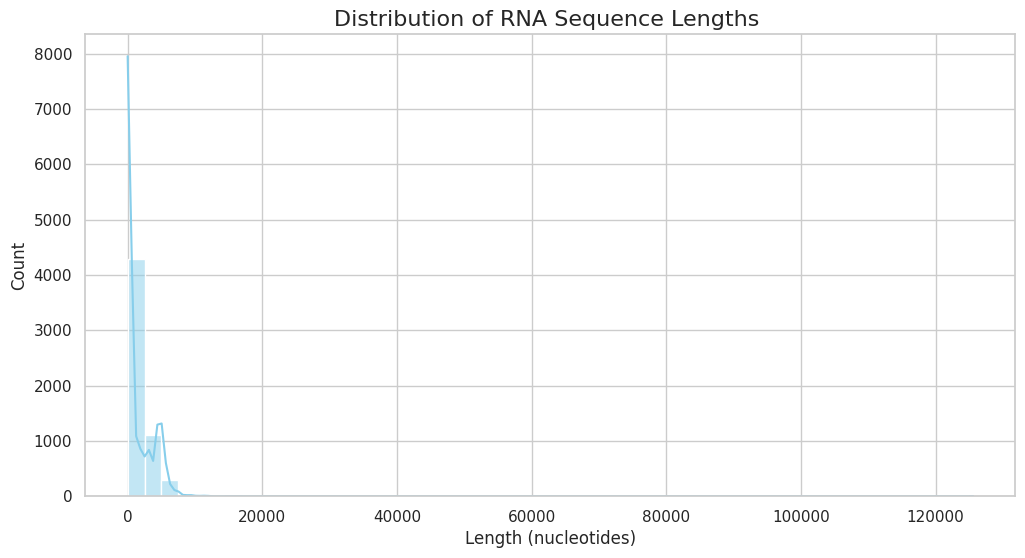

In [3]:
# Calculate length
df_seq['length'] = df_seq['sequence'].apply(len)

# 📈 Plot histogram
plt.figure(figsize=(12, 6))
sns.histplot(df_seq['length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of RNA Sequence Lengths ', fontsize=16)
plt.xlabel('Length (nucleotides)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

## 3. Character Distribution 🧬

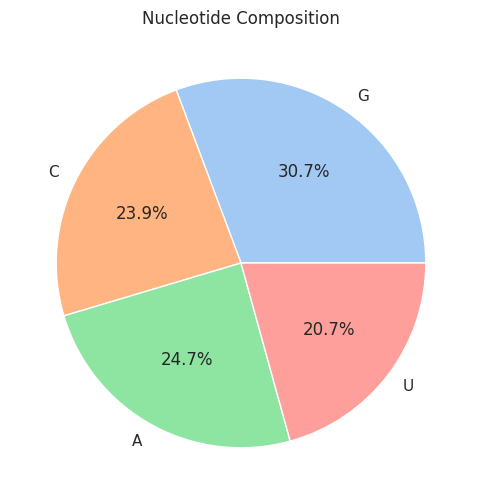

In [4]:
all_chars = ''.join(df_seq['sequence'].tolist())
char_counts = Counter(all_chars)

plt.figure(figsize=(6, 6))
plt.pie(char_counts.values(), labels=char_counts.keys(), autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Nucleotide Composition')
plt.show()

## 4. Ligand Analysis 💊
Understanding what binds to the RNA structure (ions like Mg2+, drugs, etc.) is critical for 3D folding.
Let's see the most common ligands in the dataset.

Total unique ligands found: 743


/tmp/ipykernel_17/46629113.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(top_ligands.values()), y=list(top_ligands.keys()), palette='viridis')


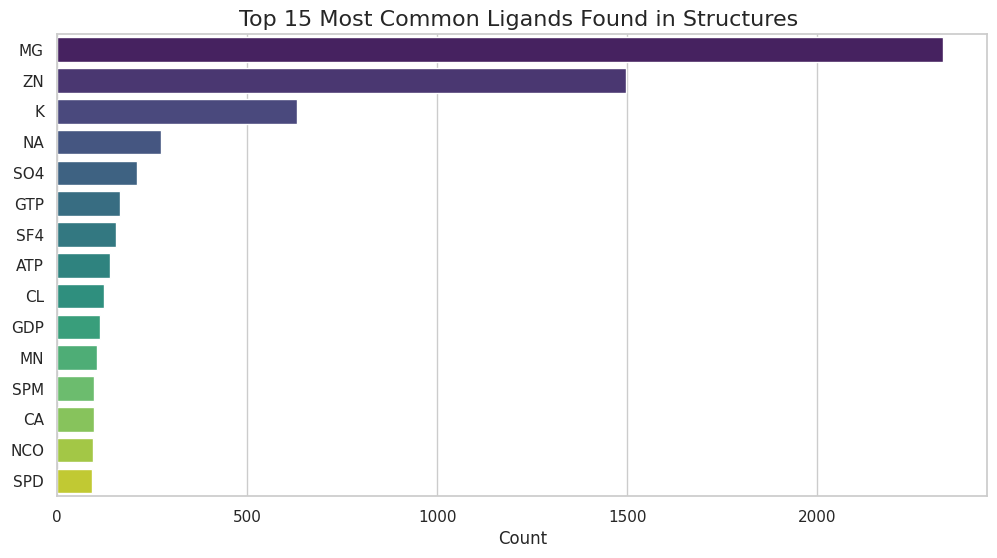

In [5]:
# Filter out NaNs and split multiple ligands (separated by ';')
ligands_series = df_seq['ligand_ids'].dropna().astype(str)
all_ligands = []
for s in ligands_series:
    all_ligands.extend(s.split(';'))

ligand_counts = Counter(all_ligands)
print(f"Total unique ligands found: {len(ligand_counts)}")

# Plot top 15 ligands
top_ligands = dict(ligand_counts.most_common(15))

plt.figure(figsize=(12, 6))
sns.barplot(x=list(top_ligands.values()), y=list(top_ligands.keys()), palette='viridis')
plt.title('Top 15 Most Common Ligands Found in Structures ', fontsize=16)
plt.xlabel('Count')
plt.show()

## 5. Stoichiometry (Complexes) 🧩
Part 2 of the competition introduces complexes (multiple chains). Let's look at the `stoichiometry` column to understand the variety.
Examples:
- `A:1` : Single chain, one copy.
- `A:1,B:1` : Heterodimer (Two different chains).
- `A:2` : Homodimer (Same chain, 2 copies).

/tmp/ipykernel_17/1202514021.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stoich_counts.values, y=stoich_counts.index, palette='magma')


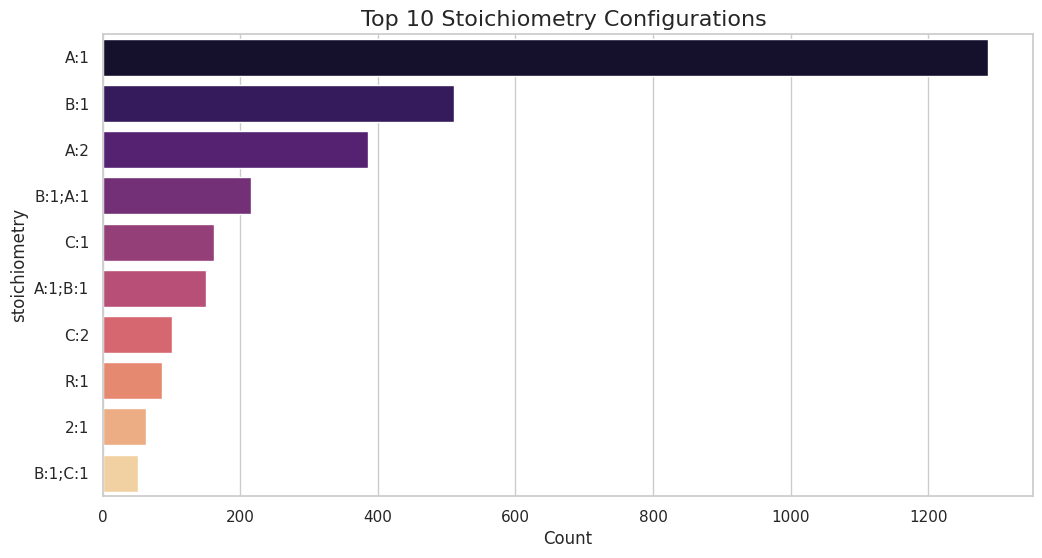

In [6]:
stoich_counts = df_seq['stoichiometry'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=stoich_counts.values, y=stoich_counts.index, palette='magma')
plt.title('Top 10 Stoichiometry Configurations ', fontsize=16)
plt.xlabel('Count')
plt.show()

## 6. WordCloud of Descriptions ☁️
What kind of RNAs are we dealing with? Ribosomes? Riboswitches? Let's check the descriptions.

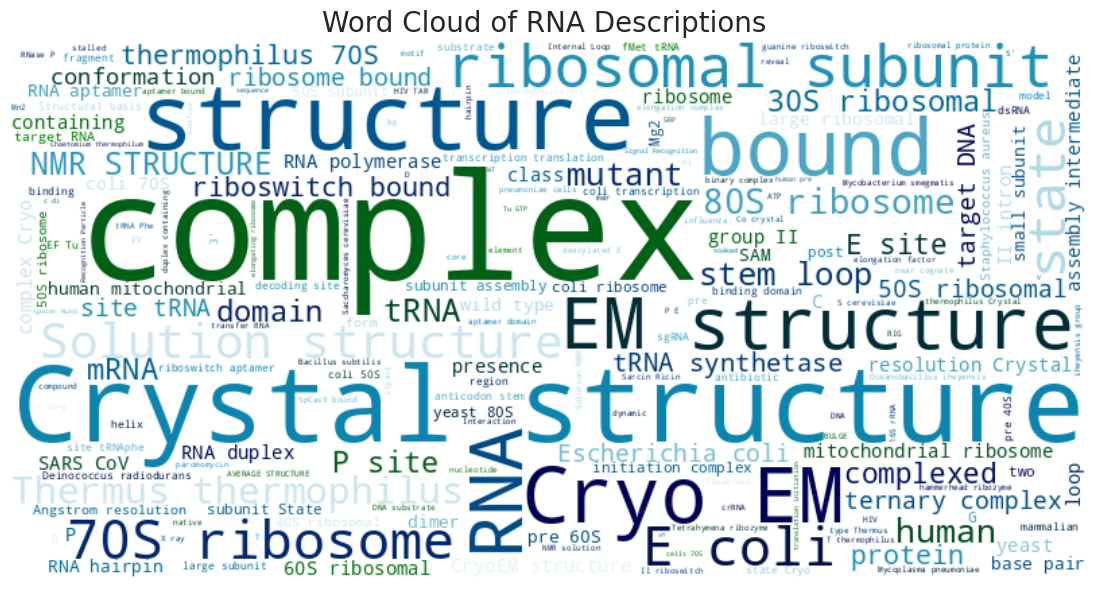

In [7]:
text = " ".join(title for title in df_seq.description.dropna())

# Create WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='ocean').generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Word Cloud of RNA Descriptions ', fontsize=20)
plt.show()

## 7. Visualizing 3D Structure 🧊
Finally, visualization of the C1' coordinates.

⏳ Loading train_labels.csv...


/tmp/ipykernel_17/595748339.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_labels = pd.read_csv(f'{BASE_DIR}/train_labels.csv')


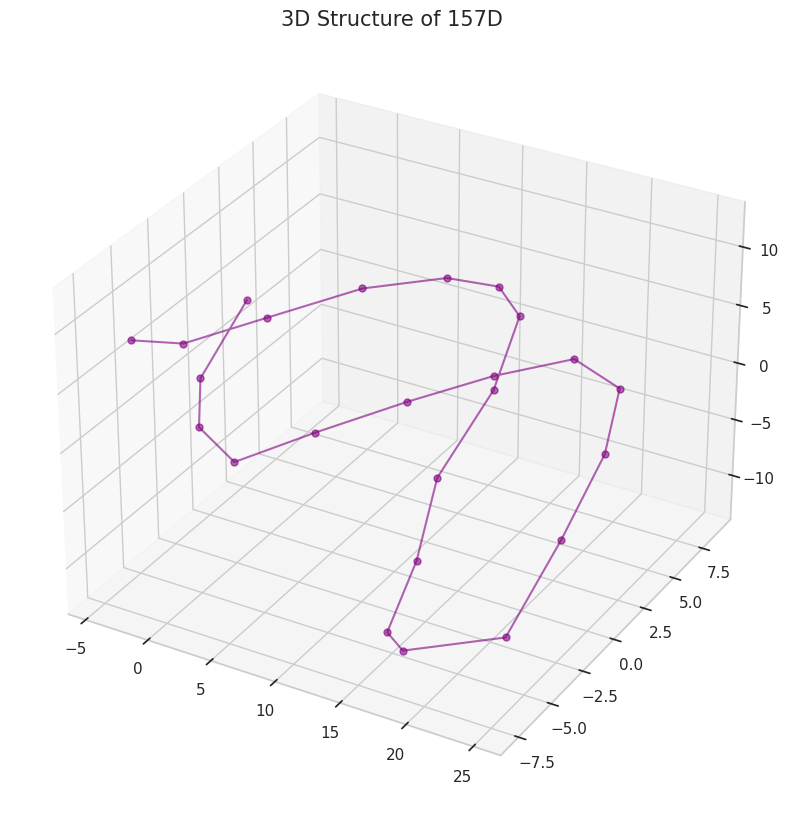

In [8]:
print("⏳ Loading train_labels.csv...")
df_labels = pd.read_csv(f'{BASE_DIR}/train_labels.csv')

target_id_sample = "157D"
sample_coords = df_labels[df_labels['ID'].astype(str).str.startswith(target_id_sample)]

if not sample_coords.empty:
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Use x_1, y_1, z_1
    ax.plot(sample_coords['x_1'], sample_coords['y_1'], sample_coords['z_1'], 
            marker='o', linestyle='-', markersize=5, alpha=0.6, color='purple')
    
    ax.set_title(f'3D Structure of {target_id_sample} ', fontsize=15)
    plt.show()
else:
    print("❌ Target not found.")

## Conclusion 🏆
This expanded EDA gives us a much better understanding of the dataset diversity (ligands, complexes, types). Good luck with your modeling!